# Graph analysis using conventional tools and GPU acceleration

Idea: run variations of bfs algorithms, implemented using different analysis libraries. 

Measure performance, compare timings, enable gpu-acceleration, try to write dedicated bfs using raw opencl.

## Setup

In [1]:
import os
import numpy as np
import scipy as sk
import networkx as nx
import pyopencl as cl
import matplotlib.pyplot as plt

## Dataset

In [2]:
graph_name = 'amazon-2008.mtx'

### Load graph from Matrix-Market format

In [3]:
G_csr = sk.io.mmread(graph_name).tocsr()

### Minimal stats

In [4]:
n_rows, n_cols = G_csr.shape
n_edges = G_csr.nnz
degrees = np.diff(G_csr.indptr)

print(f"Graph: {graph_name}")
print(f"Shape: {n_rows} x {n_cols}")
print(f"NNZ: {n_edges}")
print(f"Density: {n_edges / (n_rows * n_cols):.3e}")
print(f"Degree: mean={degrees.mean():.2f}, median={np.median(degrees):.2f}, max={degrees.max()}\n")

Graph: amazon-2008.mtx
Shape: 735323 x 735323
NNZ: 5158388
Density: 9.540e-06
Degree: mean=7.02, median=10.00, max=10



### Nodes distribution and degree profile

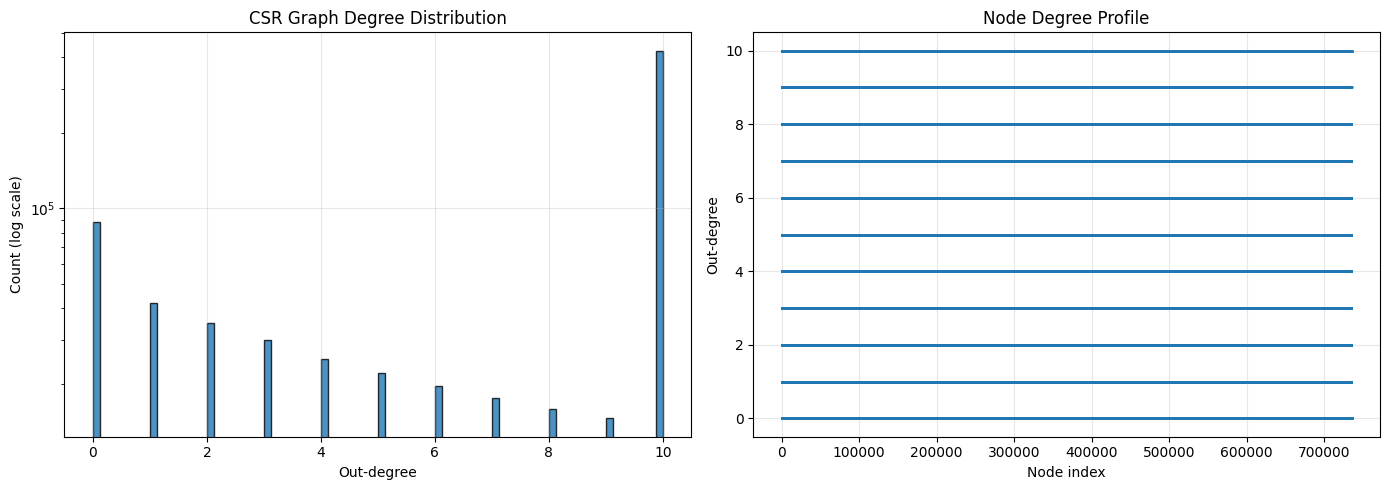

In [5]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.hist(degrees, bins=80, color='C0', edgecolor='black', alpha=0.8, log=True)
plt.xlabel('Out-degree')
plt.ylabel('Count (log scale)')
plt.title('CSR Graph Degree Distribution')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(degrees, marker='.', linestyle='none', markersize=2, alpha=0.7)
plt.xlabel('Node index')
plt.ylabel('Out-degree')
plt.title('Node Degree Profile')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis

### Naive

In [6]:
def bfs_layers(G, source):
    visited = np.zeros(G.shape[0], dtype=int)
    layers = []
    current_layer = [source]
    visited[source] = 1

    while current_layer:
        layers.append(current_layer)
        next_layer = []
        for node in current_layer:
            for neighbor in G.indices[G.indptr[node]:G.indptr[node+1]]:
                if visited[neighbor] == 0:
                    next_layer.append(neighbor)
                    visited[neighbor] = 1
        current_layer = next_layer
    
    return layers

In [7]:
def bfs_orders(G, source):
    visited = np.zeros(G.shape[0], dtype=int)
    order = np.empty(G.shape[0], dtype=int)
    predecessors = np.full(G.shape[0], -1, dtype=int)
    queue = [source]
    visited[source] = 1

    next_in_order = 0

    while queue:
        node = queue.pop(0)
        order[next_in_order] = node
        next_in_order += 1
        for neighbor in G.indices[G.indptr[node]:G.indptr[node+1]]:
            if visited[neighbor] == 0:
                queue.append(neighbor)
                visited[neighbor] = 1
                predecessors[neighbor] = node

    order.resize(next_in_order)
    return order, predecessors

In [8]:
%%time
naive_layers = bfs_layers(G_csr, source=0)
print(f"Number of layers: {len(naive_layers)}")
print(f"Nodes in first 10 layers: {[len(layer) for layer in naive_layers[:10]]}")

Number of layers: 30
Nodes in first 10 layers: [1, 7, 55, 290, 1190, 4419, 15164, 47744, 107733, 149391]
CPU times: total: 2.06 s
Wall time: 2.06 s


In [9]:
%%time
if n_edges < 6000000:
    naive_order, naive_predecessors = bfs_orders(G_csr, source=0)
    print(f"Number of orders: {len(naive_order)}")
    print(f"First 10 nodes in BFS order: {[int(i) for i in naive_order[:10]]}")
    print(f"First 10 predecessors: {[int(i) for i in naive_predecessors[naive_order[:10]]]}")

Number of orders: 735323
First 10 nodes in BFS order: [0, 1, 63599, 63670, 389305, 536016, 536102, 598597, 452950, 592883]
First 10 predecessors: [-1, 0, 0, 0, 0, 0, 0, 0, 1, 1]
CPU times: total: 16.6 s
Wall time: 16.6 s


In [10]:
naive_layers, naive_order, naive_predecessors = None, None, None

### NetworkX bfs

In [11]:
G_nx = None

if n_edges < 6000000: 
    G_nx = nx.from_scipy_sparse_array(G_csr, create_using=nx.DiGraph)

In [12]:
%%time
if G_nx:
    nx_layers = nx.bfs_layers(G_nx, [0])
    nx_layers_list = list(nx_layers)
    print(f"Number of BFS layers (NetworkX): {len(nx_layers_list)}")
    print(f"Nodes in first 10 BFS layers (NetworkX): {[len(layer) for layer in nx_layers_list[:10]]}")

Number of BFS layers (NetworkX): 30
Nodes in first 10 BFS layers (NetworkX): [1, 7, 55, 290, 1190, 4419, 15164, 47744, 107733, 149391]
CPU times: total: 1.22 s
Wall time: 1.21 s


In [13]:
%%time
if G_nx:
    nx_order = nx.bfs_tree(G_nx, source=0)
    print(f"First 10 nodes in BFS order (NetworkX): {list(nx_order)[:10]}")

First 10 nodes in BFS order (NetworkX): [0, 1, 63599, 63670, 389305, 536016, 536102, 598597, 452950, 592883]
CPU times: total: 9.58 s
Wall time: 9.58 s


In [14]:
%%time
if G_nx:
    nx_predecessors = nx.bfs_predecessors(G_nx, source=0)
    print(f"First 10 predecessors (NetworkX): {list(nx_predecessors)[:10]}")

First 10 predecessors (NetworkX): [(1, 0), (63599, 0), (63670, 0), (389305, 0), (536016, 0), (536102, 0), (598597, 0), (452950, 1), (592883, 1), (63595, 63599)]
CPU times: total: 5.19 s
Wall time: 5.19 s


In [15]:
G_nx = None

### SciPy bfs

In [16]:
%%timeit
sk_order, sk_predecessors = sk.sparse.csgraph.breadth_first_order(G_csr, 0, directed=True, return_predecessors=True)
print(f"First 10 nodes in BFS order: {sk_order[:10]}")
print(f"Predecessors of first 10 nodes: {sk_predecessors[sk_order[:10]]}")

First 10 nodes in BFS order: [     0      1  63599  63670 389305 536016 536102 598597 452950 592883]
Predecessors of first 10 nodes: [-9999     0     0     0     0     0     0     0     1     1]
First 10 nodes in BFS order: [     0      1  63599  63670 389305 536016 536102 598597 452950 592883]
Predecessors of first 10 nodes: [-9999     0     0     0     0     0     0     0     1     1]
First 10 nodes in BFS order: [     0      1  63599  63670 389305 536016 536102 598597 452950 592883]
Predecessors of first 10 nodes: [-9999     0     0     0     0     0     0     0     1     1]
First 10 nodes in BFS order: [     0      1  63599  63670 389305 536016 536102 598597 452950 592883]
Predecessors of first 10 nodes: [-9999     0     0     0     0     0     0     0     1     1]
First 10 nodes in BFS order: [     0      1  63599  63670 389305 536016 536102 598597 452950 592883]
Predecessors of first 10 nodes: [-9999     0     0     0     0     0     0     0     1     1]
First 10 nodes in BFS ord

In [17]:
%%timeit
sk_tree = sk.sparse.csgraph.breadth_first_tree(G_csr, 0, directed=True)
print(f"Number of edges in BFS tree: {sk_tree.nnz}")

Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree: 735322
Number of edges in BFS tree:

In [18]:
sk_order, sk_predecessors, sk_tree = None, None, None

### OpenCL bfs

#### Setup

In [19]:
os.environ['PYOPENCL_COMPILER_OUTPUT'] = '1'

In [20]:
for platform in cl.get_platforms():
    print(f"Platform: {platform.name}")
    
    for device in platform.get_devices():
        print(f"\tDevice: {device.name}")
        print(f"\t\tType: {cl.device_type.to_string(device.type)}")
        print(f"\t\tCompute Units: {device.max_compute_units}")
        print(f"\t\tGlobal Memory: {device.global_mem_size / (1024**3):.2f} GB")
        print(f"\t\tMax Work Group Size: {device.max_work_group_size}")
        print(f"\t\tVersion: {device.version}")

Platform: NVIDIA CUDA
	Device: Quadro T2000
		Type: ALL | GPU
		Compute Units: 16
		Global Memory: 4.00 GB
		Max Work Group Size: 1024
		Version: OpenCL 3.0 CUDA
Platform: Intel(R) OpenCL HD Graphics
	Device: Intel(R) UHD Graphics 630
		Type: ALL | GPU
		Compute Units: 24
		Global Memory: 6.29 GB
		Max Work Group Size: 256
		Version: OpenCL 3.0 NEO 


In [21]:
platform = cl.get_platforms()[0]
print(f"Using platform: {platform.name}")

Using platform: NVIDIA CUDA


In [22]:
context = cl.Context(dev_type=cl.device_type.GPU, properties=[(cl.context_properties.PLATFORM, platform)])
print(f"Context created with devices: {[device.name for device in context.devices]}")

Context created with devices: ['Quadro T2000']


In [23]:
queue = cl.CommandQueue(context)
print(f"Command queue created on device: {queue.device.name}")

Command queue created on device: Quadro T2000


In [24]:
G_cl = dict(
    indptr=cl.Buffer(context, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, hostbuf=G_csr.indptr.astype(np.int32)),
    indices=cl.Buffer(context, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, hostbuf=G_csr.indices.astype(np.int32)),
    data=cl.Buffer(context, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, hostbuf=G_csr.data.astype(np.float32)),
    shape=np.array(G_csr.shape, dtype=np.int32))         

In [25]:
cl_program = cl.Program(context, """
__kernel void bfs_orders(
    __global const int* indptr,
    __global const int* indices,
    const int write_offset,
    __global int* order,
    __global int* predecessors,
    __global int* visited,
    __global int* queue,
    const int queue_size,
    __global int* queue_next,
    __global int* queue_next_size)
{
    int i = get_global_id(0);
    if (i < queue_size) {
        int node = queue[i];
        order[write_offset + i] = node;
        for (int j = indptr[node]; j < indptr[node + 1]; j++) {
            int neighbor = indices[j];
            if (atomic_cmpxchg(&visited[neighbor], 0, 1) == 0) {
                int pos = atomic_inc(queue_next_size);
                queue_next[pos] = neighbor;
                predecessors[neighbor] = node;
            }
        }
    }
}
""").build()

In [26]:
def bfs_orders_cl(G_cl, source):
    cl_flags_rw = cl.mem_flags.READ_WRITE

    n = G_cl['shape'][0]
    int_size = np.dtype(np.int32).itemsize

    cl_visited = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_order = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_predecessors = cl.Buffer(context, cl_flags_rw, size=n * int_size) 
    cl_queue = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_queue_next = cl.Buffer(context,cl_flags_rw, size=n * int_size) 
    cl_queue_next_size = cl.Buffer(context,cl_flags_rw, size=int_size)    

    cl.enqueue_fill_buffer(queue, cl_visited, np.int32(0), offset=0, size=n * int_size)
    cl.enqueue_fill_buffer(queue, cl_predecessors, np.int32(-1), offset=0, size=n * int_size)
    
    cl.enqueue_fill_buffer(queue, cl_visited, np.int32(1), offset=source * int_size, size=int_size)
    cl.enqueue_copy(queue, cl_queue, np.array([source], dtype=np.int32))

    cpu_queue_next_size = np.empty(1, dtype=np.int32)

    queue_size = 1
    write_offset = 0
    while queue_size > 0:   
        cl.enqueue_fill_buffer(queue, cl_queue_next_size, np.int32(0), offset=0, size=int_size)

        cl_program.bfs_orders(queue,
            (queue_size,), None,
            G_cl['indptr'], G_cl['indices'],
            np.int32(write_offset),
            cl_order, cl_predecessors, 
            cl_visited, 
            cl_queue, np.int32(queue_size),
            cl_queue_next, cl_queue_next_size)

        write_offset += queue_size

        cl.enqueue_copy(queue, cpu_queue_next_size, cl_queue_next_size)
        queue_size = cpu_queue_next_size[0]

        if queue_size > 0:
            cl_queue, cl_queue_next = cl_queue_next, cl_queue

    order = np.empty(n, dtype=np.int32)
    predecessors = np.empty(n, dtype=np.int32)   
    cl.enqueue_copy(queue, order, cl_order)
    cl.enqueue_copy(queue, predecessors, cl_predecessors)
    return order, predecessors

In [27]:
%%timeit
cl_order, cl_predecessors = bfs_orders_cl(G_cl, source=0)
print(f"First 10 nodes in BFS order (OpenCL): {cl_order[:10]}")
print(f"Predecessors of first 10 nodes (OpenCL): {cl_predecessors[cl_order[:10]]}") 

First 10 nodes in BFS order (OpenCL): [     0      1  63599  63670 389305 536016 536102 598597  16816  61508]
Predecessors of first 10 nodes (OpenCL): [    -1      0      0      0      0      0      0      0  63670 536016]
First 10 nodes in BFS order (OpenCL): [     0      1  63599  63670 389305 536016 536102 598597  16816  61508]
Predecessors of first 10 nodes (OpenCL): [    -1      0      0      0      0      0      0      0  63670 536016]
First 10 nodes in BFS order (OpenCL): [     0      1  63599  63670 389305 536016 536102 598597  16816  61508]
Predecessors of first 10 nodes (OpenCL): [    -1      0      0      0      0      0      0      0  63670 536016]
First 10 nodes in BFS order (OpenCL): [     0      1  63599  63670 389305 536016 536102 598597  16816  61508]
Predecessors of first 10 nodes (OpenCL): [    -1      0      0      0      0      0      0      0  63670 536016]
First 10 nodes in BFS order (OpenCL): [     0      1  63599  63670 389305 536016 536102 598597  16816  61508